# Lung sounds analysis

Lung sounds are recordings captured from the chest with a digital stethoscope. They can reveal useful clinical patterns, such as crackles and wheezes, that are not always easy to detect by ear alone, and help to identify various diseases and clinical conditions.

## Datasets

### ICBHI 2017

- An open access database for the evaluation of respiratory sound classification algorithms
 (https://iopscience.iop.org/article/10.1088/1361-6579/ab03ea).
- Data available at: https://bhichallenge.med.auth.gr/ICBHI_2017_Challenge.

In [1]:
import os
import glob
import zipfile
import librosa
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import Audio

from torch.utils.data import Dataset

#### Data Loading

Downloading the dataset

In [2]:
data_path = "data/"
dataset1_path = os.path.join(data_path, "ICBHI_final_database")

if not os.path.exists(dataset1_path):
    print("Downloading ICBHI dataset...")
    url = "https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_final_database.zip"
    response = requests.get(url, timeout=30, verify=False)
    response.raise_for_status()

    with open("data/ICBHI_final_database.zip", "wb") as f:
        f.write(response.content)

    print("Extracting ICBHI dataset...")
    with zipfile.ZipFile("data/ICBHI_final_database.zip", "r") as zip_ref:
        zip_ref.extractall(data_path)
print("Done!")

Done!


Downloading extra files that contains demographic informations, diagnosis and training/test splits.

In [3]:
extra_files = [
    "ICBHI_Challenge_demographic_information.txt",
    "ICBHI_Challenge_diagnosis.txt",
    "ICBHI_challenge_train_test.txt",
]

for wav_file_name in extra_files:
    file_path = os.path.join(dataset1_path, wav_file_name)
    if os.path.exists(file_path):
        continue

    print(f"Downloading {wav_file_name}...")
    url = f"https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/{wav_file_name}"
    response = requests.get(url, timeout=30, verify=False)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

print("All required ICBHI files are available.")

All required ICBHI files are available.


#### Audio Sample

Example file path: data/ICBHI_final_database/107_2b4_Lr_mc_AKGC417L.wav
Audio shape: (441000,)
Sample rate: 22050
Duration: 20.00 seconds


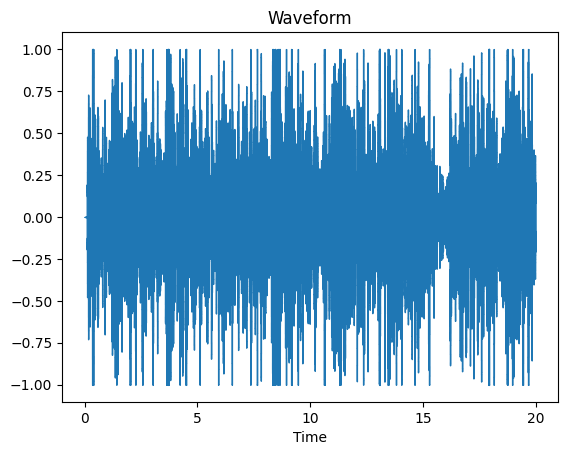

In [4]:
# Load a random audio file from the dataset
wav_files = glob.glob(os.path.join(dataset1_path, "**/*.wav"), recursive=True)
filename = np.random.choice(wav_files)
print(f"Example file path: {filename}")

# Load the audio file
audio, sr = librosa.load(filename)
print(f"Audio shape: {audio.shape}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(audio) / sr:.2f} seconds")

# Plot the audio waveform
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform')
plt.show()

# Play the audio
Audio(data=audio, rate=sr)

#### LungSound class

In [5]:
class LungSound():
    """
    Class to represent a lung sound recording and its associated metadata.
    """
    def __init__(self, file_path):
        self.wav_file = file_path
        self.text_file = file_path.replace(".wav", ".txt")
        self._load_audio()
        self._load_annotations()

    def _load_audio(self):
        # Load the audio file
        self.audio, self.sr = librosa.load(self.wav_file)

    def _load_annotations(self):
        # Load the annotation file
        columns = ["StartTime", "EndTime", "Crackle", "Wheeze"]
        self.annotations = pd.read_csv(self.text_file, names=columns, delimiter= '\t')

    def get_metadata(self):
        wav_file_name = os.path.basename(self.wav_file)
        parts = wav_file_name.split("_")
        return {
            "FileName": wav_file_name.split(".")[0],  # Remove file extension
            "PatientNumber": parts[0],
            "RecordingIndex": parts[1],
            "ChestLocation": parts[2],
            "AcquisitionMode": parts[3],
            "RecordingEquipment": parts[4].split(".")[0]  # Remove file extension
        }

    def plot_waveform(self, title=None, ax=None):
        # Plot the audio waveform
        if title is None:
            title = f"{self.get_metadata()['FileName']}"
        if ax is None:
            librosa.display.waveshow(self.audio, sr=self.sr)
            plt.title(f"{title}")
            plt.show()
        else:
            librosa.display.waveshow(self.audio, sr=self.sr, ax=ax)
            ax.set_title(f"{title}")

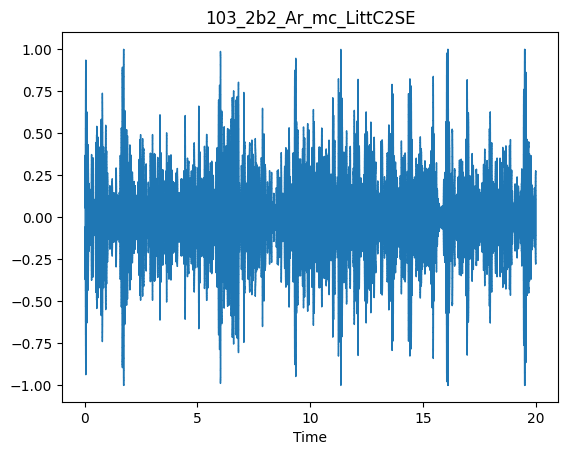

,StartTime,EndTime,Crackle,Wheeze
0,0.364,3.250,0,1
1,3.250,6.636,0,0
2,6.636,11.179,0,1
3,11.179,14.250,0,1
4,14.250,16.993,0,1
5,16.993,19.979,0,0


In [6]:
filename = os.path.join(dataset1_path, "103_2b2_Ar_mc_LittC2SE.wav")
lung_sound = LungSound(filename)
lung_sound.plot_waveform()
display(lung_sound.annotations)
Audio(data=lung_sound.audio, rate=lung_sound.sr)

#### Spectrograms

A standard spectrogram is built from the Short-Time Fourier Transform (STFT). The Fourier transform tells us which frequencies are present in a signal, but a normal Fourier transform loses time information. The STFT fixes that by splitting the signal into short overlapping windows and applying Fourier analysis to each window. If $x[n]$ is the audio signal and $w[n-t]$ is a window centered at time $t$, the STFT is

$$
X(t, f) = \sum_{n=-\infty}^{\infty} x[n] \, w[n-t] \, e^{-j 2 \pi f n}
$$

The spectrogram usually displays the magnitude $|X(t,f)|$, often converted to decibels:

$$
S_{dB} = 10 \log_{10}(S)
$$

This view is useful because it shows when energy appears and at which frequencies it is concentrated. In lung sound analysis, crackles, wheezes, and other abnormal patterns can leave visible traces in these time-frequency maps.

Spectrogram shape: (1025, 862)


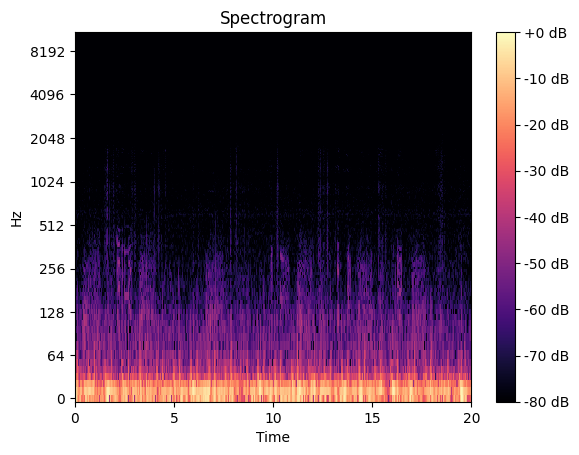

In [7]:
# Compute Short-Time Fourier Transform (STFT)
stft = librosa.stft(lung_sound.audio)
# Compute the magnitude of the STFT to get the spectrogram
spectrogram = np.abs(stft)
# Convert the amplitude spectrogram to decibel (dB) units
spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
# Display the spectrogram
print(f"Spectrogram shape: {spectrogram_db.shape}")
librosa.display.specshow(spectrogram_db, sr=lung_sound.sr, x_axis='time', y_axis='log')
plt.title('Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()

The Mel spectrogram changes the frequency axis to the Mel scale. The idea is: human hearing does not perceive frequency linearly, so the Mel scale spreads low frequencies more and compresses high frequencies. This can make relevant patterns easier for models to learn from.

The result is still a time-frequency representation, but with a frequency axis that is closer to how we listen.

Mel Spectrogram shape: (128, 862)


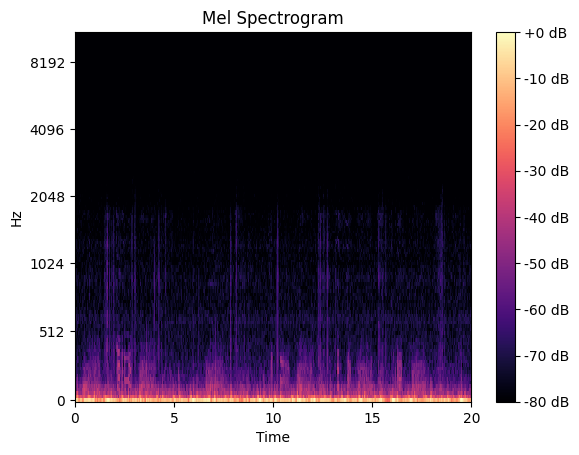

In [8]:
# Compute the Mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=lung_sound.audio, sr=lung_sound.sr)
# Convert the Mel spectrogram to decibel (dB) units
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
# Display the Mel spectrogram
print(f"Mel Spectrogram shape: {mel_spectrogram_db.shape}")
librosa.display.specshow(mel_spectrogram_db, sr=lung_sound.sr, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

MFCCs, or Mel-Frequency Cepstral Coefficients, are a compact summary of the spectrum. They start from the log Mel spectrogram and then apply a discrete cosine transform, which keeps the broad shape of the spectral envelope while discarding more detailed variation.

This is especially useful when we want a small set of features that still captures how energy is distributed across frequencies over time.

MFCCs shape: (20, 862)


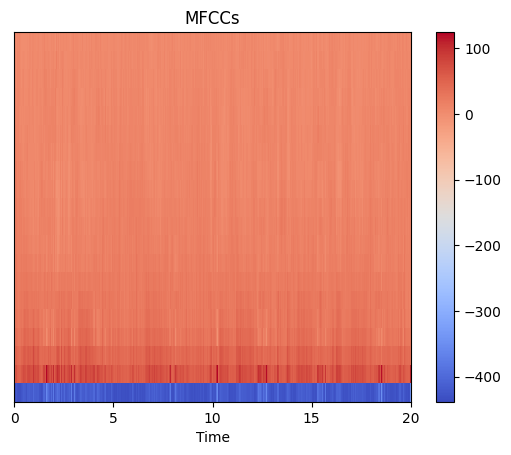

In [9]:
# Compute the MFCCs
mfccs = librosa.feature.mfcc(y=lung_sound.audio, sr=lung_sound.sr)
# Display the MFCCs
print(f"MFCCs shape: {mfccs.shape}")
librosa.display.specshow(mfccs, sr=lung_sound.sr, x_axis='time')
plt.title('MFCCs')
plt.colorbar()
plt.show()

#### Dataset class

In [10]:
class ICBHIDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self._load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.data.iloc[idx]["WavFile"])
        audio = LungSound(file_path)
        label = self.data.iloc[idx]["Diagnosis"]
        return audio, label

    def _load_data(self):
        data = []
        annot = []
        for file in sorted(glob.glob(os.path.join(self.data_dir, "*.wav"))):
            wav_file = os.path.basename(file)
            text_file = os.path.splitext(file)[0] + ".txt"
            data.append(wav_file)
            annot.append(self.extract_metadata(text_file))

        diagnosis_file = os.path.join(self.data_dir, "ICBHI_Challenge_diagnosis.txt")
        diagnosis_df = pd.read_csv(
            diagnosis_file, names=["PatientNumber", "Diagnosis"], delimiter='\t',
            dtype={"PatientNumber": str, "Diagnosis": str}
        )
        data = pd.DataFrame({"WavFile": data})
        annot = pd.DataFrame(annot)
        self.data = pd.concat([data, annot], axis=1)
        self.data = self.data.merge(diagnosis_df, on="PatientNumber", how="left")

    def unit_test(self, idx=0):
        # Test loading a sample
        sample, label = self[idx]
        print(f"Sample: {sample.audio.shape} {sample.sr}")
        sample.plot_waveform(title=f"Diagnosis: {label}")
        display(sample.annotations)
        return sample

    @ staticmethod
    def extract_metadata(file_path):
        wav_file_name = os.path.basename(file_path)
        parts = wav_file_name.split("_")
        return {
            "FileName": wav_file_name,
            "PatientNumber": parts[0],
            "RecordingIndex": parts[1],
            "ChestLocation": parts[2],
            "AcquisitionMode": parts[3],
            "RecordingEquipment": parts[4].split(".")[0]  # Remove file extension
        }

In [11]:
dataset = ICBHIDataset(dataset1_path)
print(f"Dataset size: {len(dataset)} samples")
dataset.data.head()

Dataset size: 920 samples


,WavFile,FileName,PatientNumber,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Diagnosis
0,101_1b1_Al_sc_Meditron.wav,101_1b1_Al_sc_Meditron.txt,101,1b1,Al,sc,Meditron,URTI
1,101_1b1_Pr_sc_Meditron.wav,101_1b1_Pr_sc_Meditron.txt,101,1b1,Pr,sc,Meditron,URTI
2,102_1b1_Ar_sc_Meditron.wav,102_1b1_Ar_sc_Meditron.txt,102,1b1,Ar,sc,Meditron,Healthy
3,103_2b2_Ar_mc_LittC2SE.wav,103_2b2_Ar_mc_LittC2SE.txt,103,2b2,Ar,mc,LittC2SE,Asthma
4,104_1b1_Al_sc_Litt3200.wav,104_1b1_Al_sc_Litt3200.txt,104,1b1,Al,sc,Litt3200,COPD


#### Class distribution

Diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


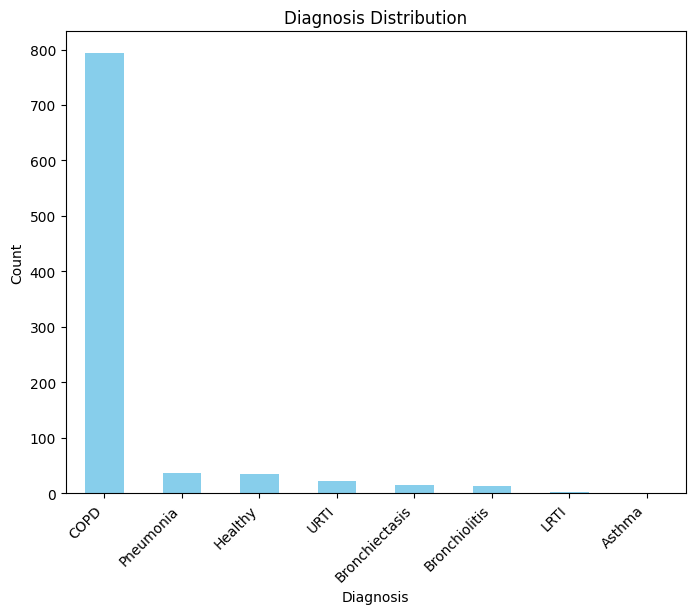

In [12]:
# Plot diagnosis distribution
diagnosis_counts = dataset.data['Diagnosis'].value_counts()
print(diagnosis_counts)
plt.figure(figsize=(8, 6))
# show number in bars
diagnosis_counts.plot(kind='bar', color='skyblue')
plt.title('Diagnosis Distribution')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.show()

Sample: (714420,) 22050


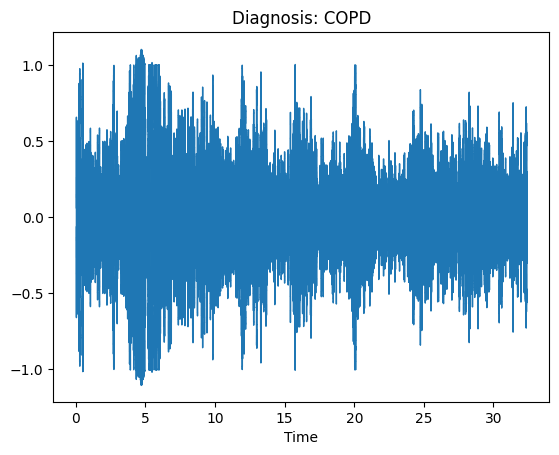

,StartTime,EndTime,Crackle,Wheeze
0,3.6457,7.601,0,1
1,7.6010,11.667,0,1
2,11.6670,15.441,0,0
3,15.4410,19.678,0,0
4,19.6780,23.855,0,1
5,23.8550,28.052,0,0
6,28.0520,32.400,0,0


In [13]:
sample = dataset.unit_test(idx=50)

### Fraiwan et al., 2021

- A dataset of lung sounds recorded from the chest wall using an electronic stethoscope (https://www.sciencedirect.com/science/article/pii/S2352340921001979).
- Data available at: https://data.mendeley.com/datasets/jwyy9np4gv/3.

In [14]:
data_path = "data/"
dataset2_path = os.path.join(data_path, "fraiwan")

if not os.path.exists(dataset2_path):
    print("Downloading fraiwan dataset...")
    url = "https://data.mendeley.com/public-api/zip/jwyy9np4gv/download/3"
    response = requests.get(url, timeout=30, verify=False)
    response.raise_for_status()

    with open("data/jwyy9np4gv-3.zip", "wb") as f:
        f.write(response.content)

    print("Extracting fraiwan dataset...")
    with zipfile.ZipFile("data/jwyy9np4gv-3.zip", "r") as zip_ref:
        zip_ref.extractall(dataset2_path)
print("Done!")

Done!


In [15]:
if not os.path.exists(dataset2_path+"/Audio Files"):
    print("Extracting fraiwan audio files...")
    with zipfile.ZipFile("data/fraiwan/Audio Files.zip", "r") as zip_ref:
        zip_ref.extractall(dataset2_path+"/Audio Files")

if not os.path.exists(dataset2_path+"/Stethoscope Files"):
    print("Extracting fraiwan stethoscope files...")
    with zipfile.ZipFile("data/fraiwan/Stethoscope Files.zip", "r") as zip_ref:
        zip_ref.extractall(dataset2_path+"/Stethoscope Files")
print("Done!")

Done!


Example file path: data/fraiwan/Audio Files/EP106_Asthma,E W,P L U,45,F.wav
Audio shape: (437120,)
Sample rate: 22050
Duration: 19.82 seconds


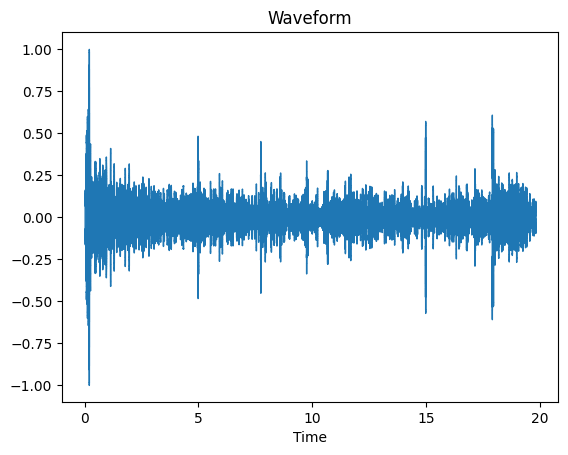

In [16]:
# Load a random audio file from the dataset
wav_files = glob.glob(os.path.join(dataset2_path, "**/*.wav"), recursive=True)
filename = np.random.choice(wav_files)
print(f"Example file path: {filename}")

# Load the audio file
audio, sr = librosa.load(filename)
print(f"Audio shape: {audio.shape}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(audio) / sr:.2f} seconds")

# Plot the audio waveform
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform')
plt.show()

# Play the audio
Audio(data=audio, rate=sr)

Diagnosis
N                                 35
Asthma                            17
heart failure                     15
asthma                            15
COPD                               8
pneumonia                          5
Lung Fibrosis                      4
Heart Failure                      3
BRON                               3
Heart Failure + COPD               2
Plueral Effusion                   2
Heart Failure + Lung Fibrosis      1
Asthma and lung fibrosis           1
copd                               1
Name: count, dtype: int64


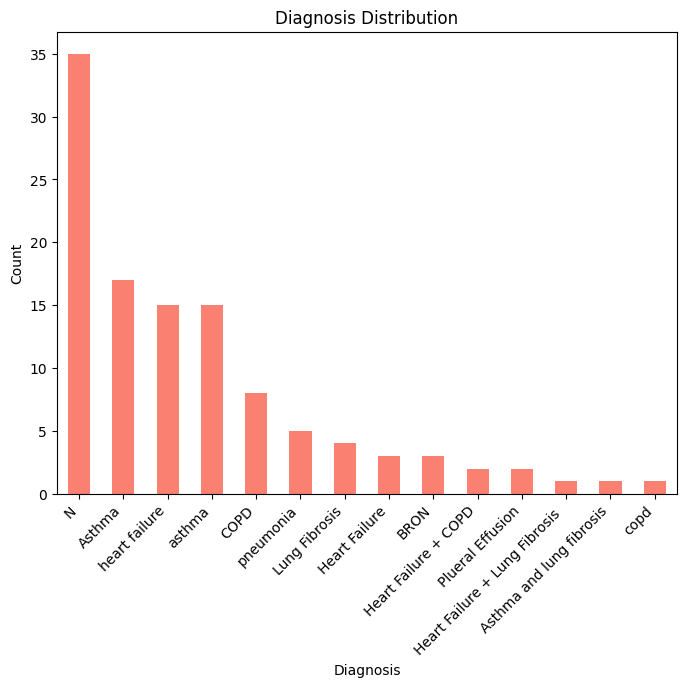

In [18]:
# read a xslx file
xlsx_file = os.path.join(dataset2_path, "Data annotation.xlsx")
annotations_df = pd.read_excel(xlsx_file)
# show distributions of "Diagnosis" column
diagnosis_counts = annotations_df['Diagnosis'].value_counts()
print(diagnosis_counts)
plt.figure(figsize=(8, 6))
# show number in bars
diagnosis_counts.plot(kind='bar', color='salmon')
plt.title('Diagnosis Distribution')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.show()